In [51]:
# Code 1: Data Load
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition[1].csv')
print("Total Employees:", len(df))
print("Attrition Rate:", round(df['Attrition'].eq('Yes').sum()/len(df)*100,1), "%")
print("Avg Salary: $", round(df['MonthlyIncome'].mean(),0))
print("Avg Age:", round(df['Age'].mean(),1))

Total Employees: 1470
Attrition Rate: 16.1 %
Avg Salary: $ 6503.0
Avg Age: 36.9


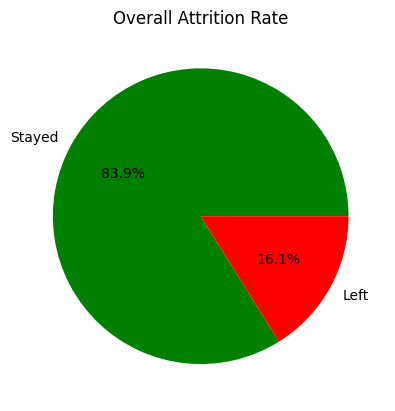

In [52]:
# Code 2:  Attrition Count - Pie Chart
sizes = df['Attrition'].value_counts()
plt.pie(sizes, labels=['Stayed','Left'], colors=['green','red'], autopct='%1.1f%%')
plt.title('Overall Attrition Rate')
plt.show()

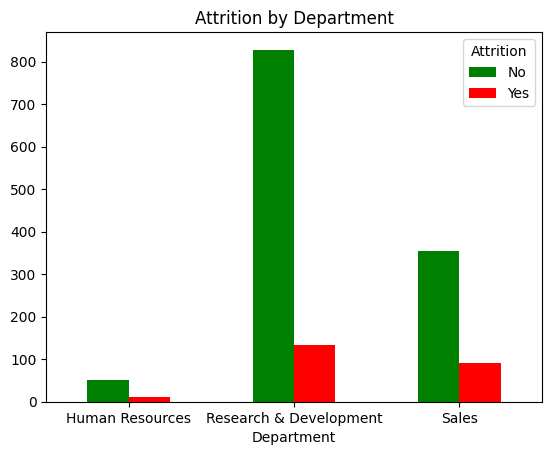

In [53]:
# Code 3: Department wise Attrition
df.groupby('Department')['Attrition'].value_counts().unstack().plot(kind='bar', color=['green','red'])
plt.title('Attrition by Department')
plt.xlabel('Department')
plt.xticks(rotation=0)
plt.show()

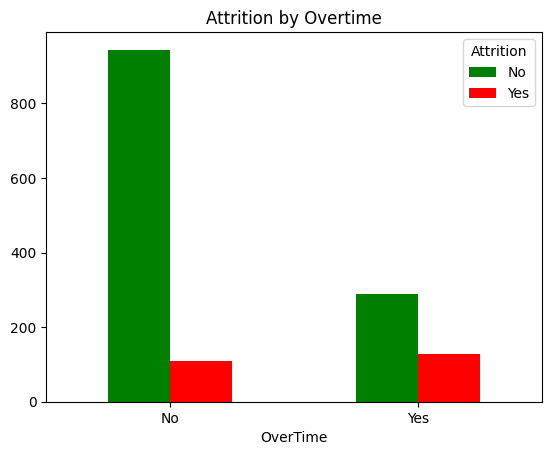

In [54]:
# Code 4: OverTime vs Attrition
df.groupby('OverTime')['Attrition'].value_counts().unstack().plot(kind='bar', color=['green','red'])
plt.title('Attrition by Overtime')
plt.xlabel('OverTime')
plt.xticks(rotation=0)
plt.show()

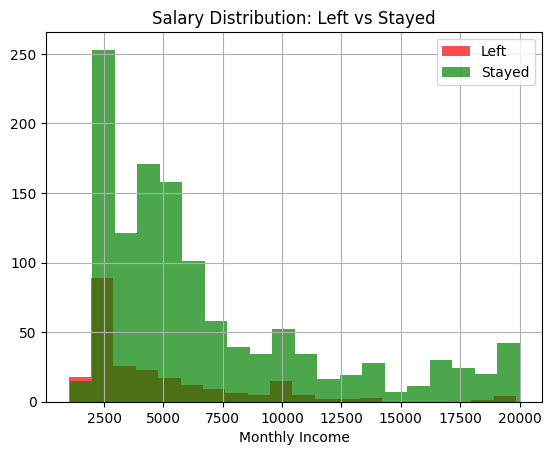

In [55]:
# Code 5: Salary Distribution
df[df['Attrition']=='Yes']['MonthlyIncome'].hist(bins=20, color='red', alpha=0.7, label='Left')
df[df['Attrition']=='No']['MonthlyIncome'].hist(bins=20, color='green', alpha=0.7, label='Stayed')
plt.title('Salary Distribution: Left vs Stayed')
plt.xlabel('Monthly Income')
plt.legend()
plt.show()

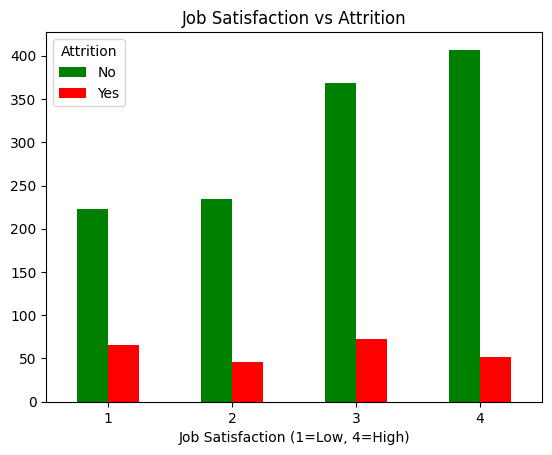

In [56]:
# Code 6: Job Satisfaction vs Attrition
df.groupby('JobSatisfaction')['Attrition'].value_counts().unstack().plot(kind='bar', color=['green','red'])
plt.title('Job Satisfaction vs Attrition')
plt.xlabel('Job Satisfaction (1=Low, 4=High)')
plt.xticks(rotation=0)
plt.show()

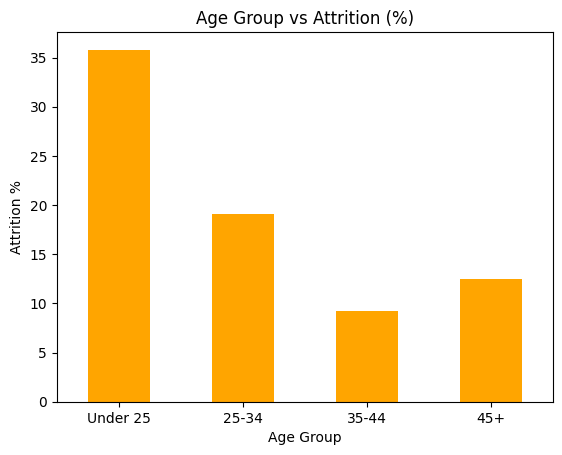

In [57]:
# Code 7: Age Group vs Attrition
df['AgeGroup'] = pd.cut(df['Age'],
    bins=[17,25,35,45,60],
    labels=['Under 25','25-34','35-44','45+'])
age = df.groupby('AgeGroup', observed=True)['Attrition'].apply(
    lambda x: round(x.eq('Yes').sum()/len(x)*100,1))
age.plot(kind='bar', color='orange')
plt.title('Age Group vs Attrition (%)')
plt.xlabel('Age Group')
plt.ylabel('Attrition %')
plt.xticks(rotation=0)
plt.show()

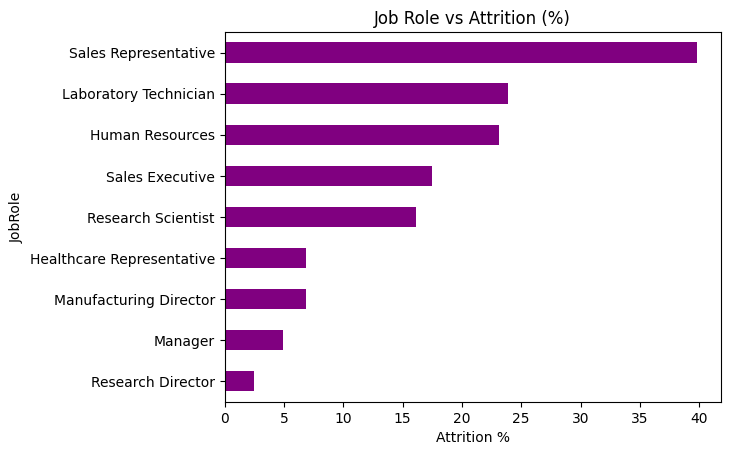

In [58]:
# Code 8: Job Role vs Attrition
role = df.groupby('JobRole')['Attrition'].apply(
    lambda x: round(x.eq('Yes').sum()/len(x)*100,1))
role.sort_values().plot(kind='barh', color='purple')
plt.title('Job Role vs Attrition (%)')
plt.xlabel('Attrition %')
plt.show()

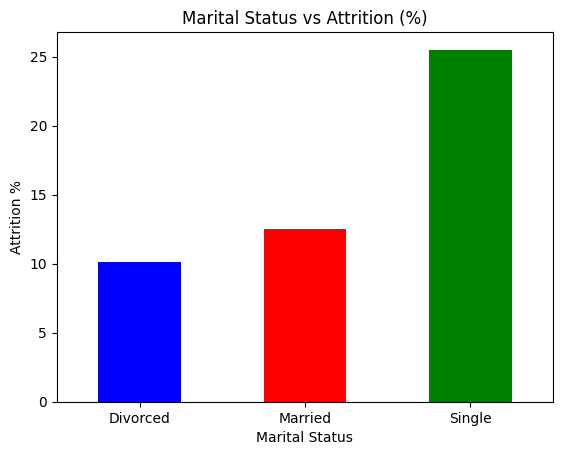

In [59]:
# Code 9: Marital Status vs Attrition
mar = df.groupby('MaritalStatus')['Attrition'].apply(
    lambda x: round(x.eq('Yes').sum()/len(x)*100,1))
mar.plot(kind='bar', color=['blue','red','green'])
plt.title('Marital Status vs Attrition (%)')
plt.xlabel('Marital Status')
plt.ylabel('Attrition %')
plt.xticks(rotation=0)
plt.show()

In [60]:
# Code 10: Key Insights Print
print("=" * 40)
print("KEY INSIGHTS")
print("=" * 40)
print("Total Employees  :", len(df))
print("Left Company     :", df['Attrition'].eq('Yes').sum())
print("Attrition Rate   :", round(df['Attrition'].eq('Yes').sum()/len(df)*100,1), "%")
print("Avg Salary (Left):", round(df[df['Attrition']=='Yes']['MonthlyIncome'].mean(),0))
print("Avg Salary (Stay):", round(df[df['Attrition']=='No']['MonthlyIncome'].mean(),0))

KEY INSIGHTS
Total Employees  : 1470
Left Company     : 237
Attrition Rate   : 16.1 %
Avg Salary (Left): 4787.0
Avg Salary (Stay): 6833.0
